# Homework

In [44]:
all_data = pd.read_csv('datasets/forest_dataset.csv')

labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

The quality of classification/regression by the k Nearest Neighbors method depends on several parameters:
* the number of neighbors `n_neighbors`
* the distance metric between objects `metric`
* the weights of neighbors (the neighbors of the test example can enter with different weights, for example, the further the example, the less its "voice" is taken into account) `weights`


Train the `KNeighborsClassifier` on the dataset.

In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

clf = KNeighborsClassifier(n_neighbors=1, weights=None, metric="euclidean")
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
accuracy_score(test_labels, y_pred)

0.783

Let's select the parameters of our model:

* Iterate over the grid from `1` to `10` for the number of neighbors parameter
* Also, try using different metrics: `['manhattan', 'euclidean']`
* Try using different weight calculation strategies: `[‘uniform’, ‘distance’]`

In [46]:
from sklearn.model_selection import GridSearchCV
params = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
clf_grid.fit(feature_matrix, labels)

GridSearchCV(cv=5,
             estimator=KNeighborsClassifier(metric='euclidean', n_neighbors=1,
                                            weights=None),
             n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

Выведем наилучшие параметры

In [47]:
clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}

Используя найденное оптимальное количество соседей, вычислим вероятности принадлежности к классам для тестовой выборки (`.predict_proba`).

In [48]:
optimal_clf = KNeighborsClassifier(n_neighbors=4, weights='distance', metric='manhattan')
optimal_clf.fit(train_feature_matrix, train_labels)
pred_prob = optimal_clf.predict_proba(test_feature_matrix)
print(pred_prob)

[[0.         1.         0.         ... 0.         0.         0.        ]
 [0.73117861 0.26882139 0.         ... 0.         0.         0.        ]
 [0.27814042 0.72185958 0.         ... 0.         0.         0.        ]
 ...
 [1.         0.         0.         ... 0.         0.         0.        ]
 [0.         1.         0.         ... 0.         0.         0.        ]
 [0.54264548 0.         0.         ... 0.         0.         0.45735452]]


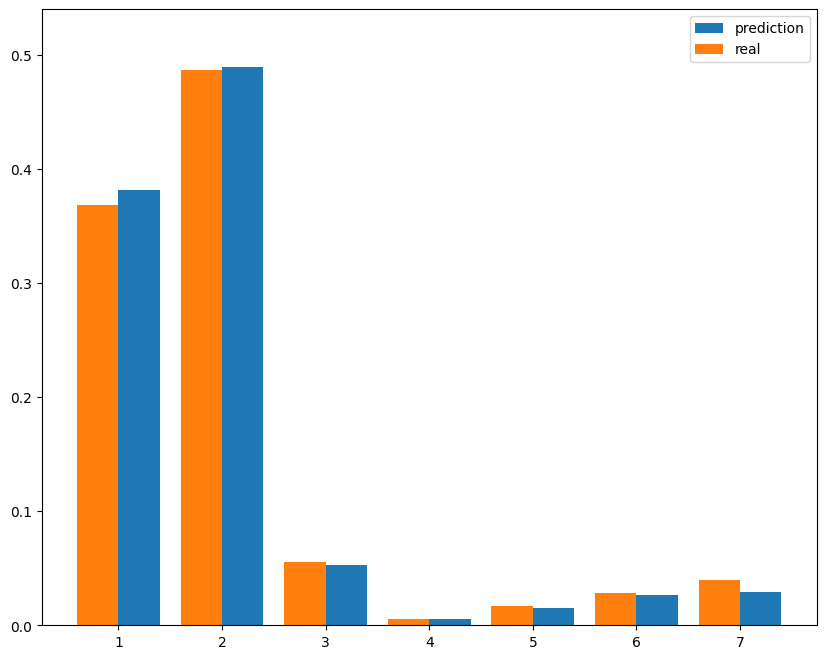

In [49]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels),freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

## Conclusion

What is the quality of the model on the test sample? Compare it with the quality of logistic regression. Which model is better? Why? What are the pros and cons of the k Nearest Neighbors method? Plot the ROC curve for the k Nearest Neighbors method. Calculate the area under the ROC curve (AUC-ROC).

What is the quality of the model on the test sample?

In [50]:
optimal_y_pred = optimal_clf.predict(test_feature_matrix)
knn_accuracy = accuracy_score(test_labels, optimal_y_pred)
print(knn_accuracy)

0.785


Compare it with the quality of logistic regression.

In [51]:
from sklearn.linear_model import LogisticRegression

clf_log = LogisticRegression(C=1, solver='lbfgs')
clf_log.fit(train_feature_matrix, train_labels)
y_pred_log = clf_log.predict(test_feature_matrix)

log_accuracy = accuracy_score(test_labels, y_pred_log)
print(log_accuracy)

0.6075


In [52]:
print(knn_accuracy - log_accuracy)

0.1775


Which model is better? Why?

Очевидно, что в нашем случае knn лучше, и мы можем видеть результаты с высокой точностью, но я думаю, что существует множество проблем, в которых логистическая регрессия будет более полезной. 
это лучше, потому что мы нашли наилучшие параметры для нашей задачи.

What are the pros and cons of the k Nearest Neighbors method?

плюсы
1. небольшое время обучения: это связано с тем, что обучение knn заключается в запоминании всех заданных объектов
2.простота: каждый может понять метод и использовать его
3.точность: он может быть очень точным, если правильно подобрать k, метрику и другие параметры

минусы
1. длинные прогнозы: он длинный из-за своей обучающей спецификации
2. параметры: точность knn сильно зависит от параметров модели, и иногда их трудно найти

Plot the ROC curve for the k Nearest Neighbors method. Calculate the area under the ROC curve (AUC-ROC).

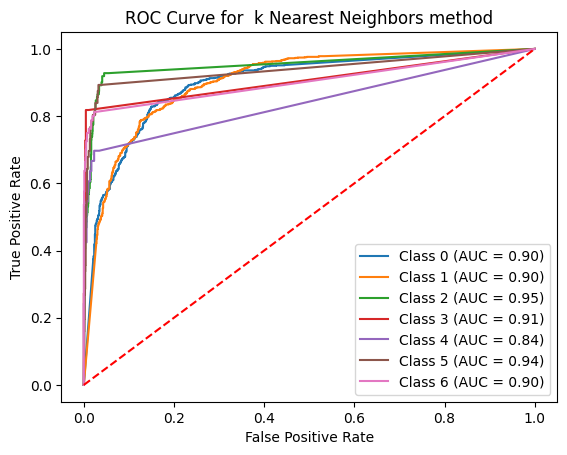

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(test_labels, classes=np.arange(1,8))
y_pred_proba = optimal_clf.predict_proba(test_feature_matrix)

plt.figure()
for i in range(7):  
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(y_pred_proba)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for  k Nearest Neighbors method')
plt.legend()
plt.show()